# Working with the actual model

In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ['HF_ROOT']

'/home/jennifer/scratch/jennifer/hf'

In [2]:
from pathlib import Path

hf_root = Path(os.environ['HF_ROOT'])
hf_root.mkdir(parents=True, exist_ok=True)
(hf_root / "transformers").mkdir(parents=True, exist_ok=True)
(hf_root / "datasets").mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(hf_root)
os.environ["TRANSFORMERS_CACHE"] = str(hf_root / "transformers")
os.environ["HF_DATASETS_CACHE"] = str(hf_root / "datasets")

print(hf_root)

/home/jennifer/scratch/jennifer/hf


In [3]:
# from datasets import load_dataset
# om_ds = load_dataset("microsoft/OpenMementos", "full", split="train")
# om_ds

## Loading the 4B model

In [4]:
# from transformers import pipeline

# pipe = pipeline("text-generation", model="Qwen/Qwen3-4B-Instruct-2507")
# messages = [
#     {"role": "user", "content": "Who are you?"},
# ]
# pipe(messages)

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    # dtype=torch.bfloat16,
    device_map="cuda",
)
model.eval()

print(f"Loaded {MODEL_ID} on {device} (4-bit NF4)")

messages = [{"role": "user", "content": "Who are you?"}]
inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

/home/jennifer/scratch/micromamba/envs/info/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:03<00:00, 125.69it/s]


Loaded Qwen/Qwen3-4B-Instruct-2507 on cuda (4-bit NF4)
I am Qwen, a large-scale language model developed by Alibaba Cloud's Tongyi Lab. I am designed to answer questions, create text such as stories, official documents, emails, scripts, and


In [6]:
system_prompt = '''
You are a STATE-COMPRESSOR for long reasoning traces produced by advanced models.
You receive the FULL reasoning trace partitioned into blocks. Your ONLY job is to produce an extremely information-dense, lemma-like STATE SUMMARY for each block.
== CORE OBJECTIVE ==
Minimize the number of tokens in each summary, subject to fully capturing all logically relevant information: - Definitions, variables, functions, data structures - Assumptions, constraints, case splits - Key intermediate results: equations, inequalities, derived identities - Chosen strategies, algorithmic ideas, invariants - Important rejected attempts
You MUST NOT: omit facts needed later, invent new facts, or paraphrase so aggressively that conclusions become ambiguous.
== NO NEW REASONING ==
Behave as a purely extractive compressor. Do NOT derive new values, repair mistakes, or re-solve the problem.
== COMPRESSION STYLE ==
Target: ∼10% of block tokens (≤20%). Terse, lemma-like, not literary. Prefer compact symbolic notation. Example: "Let f(n)=...; assume n>=3; derived f(n)=3n-2>0 for n>=3."
'''

## Evaluation on MultiHopQA

## Getting data

In [7]:
# om_ds['source'][0]

In [8]:
# om_ds['problem'][:5]

## MultihopQA

In [9]:
from datasets import load_dataset

ds = load_dataset("khaimaitien/qa-expert-multi-hop-qa-V1.0")

In [10]:
ds['train']

Dataset({
    features: ['sub_questions', 'tag', 'answer', 'question', 'meta_info', 'final_answer', 'multihop'],
    num_rows: 25547
})

In [11]:
val_ds = ds['validation']

In [12]:
import pandas as pd

def extract_answer(text):
    """Pull the text after the last 'Answer:' marker."""
    if "Answer:" in text:
        return text.split("Answer:")[-1].strip()
    return text.strip()

def build_prompt(sample):
    """Concatenate all sub-question paragraphs as context, then ask the question."""
    context_blocks = []
    for i, sq in enumerate(sample["sub_questions"], 1):
        context_blocks.append(f"[Passage {i}] {sq['paragraph'].strip()}")
    context = "\n\n".join(context_blocks)
    return (
        f"{context}\n\n"
        f"Question: {sample['question']}\n\n"
        "Think step by step, then end your response with 'Answer: <your answer>'."
    )

N_EVAL = 10

eval_results = []
for idx in range(N_EVAL):
    sample = val_ds[idx]
    prompt = build_prompt(sample)

    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_reasoning = tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    )

    model_answer = extract_answer(full_reasoning)
    gt_answer    = extract_answer(sample["final_answer"])
    correct      = model_answer.lower().strip() == gt_answer.lower().strip()

    eval_results.append({
        "idx":               idx,
        "multihop":          sample["multihop"],
        "question":          sample["question"],
        "full_reasoning":    full_reasoning,
        "model_answer":      model_answer,
        "ground_truth":      gt_answer,
        "correct":           correct,
    })

    print(f"[{idx+1}/{N_EVAL}] multihop={sample['multihop']}  correct={correct}")
    print(f"  gt:    {gt_answer[:80]}")
    print(f"  model: {model_answer[:80]}\n")
    torch.cuda.empty_cache()

df_eval = pd.DataFrame(eval_results)
df_eval

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[1/10] multihop=True  correct=False
  gt:    Nasser was the leader of Egypt, which became a colony of the Roman Empire in the
  model: 376

[2/10] multihop=False  correct=False
  gt:    I'm sorry, but based on the provided knowledge, I cannot give a specific number 
  model: Cannot be determined from the passage.

[3/10] multihop=False  correct=False
  gt:    A staple food in Tibet is roasted barley, yak meat, and butter tea.
  model: roasted barley

[4/10] multihop=False  correct=False
  gt:    I'm sorry, but I cannot answer this question based on the knowledge provided.
  model: The passage does not provide information about the camera on the Sharp Aquos R2.

[5/10] multihop=True  correct=False
  gt:    The Bald Eagle has a distinctive appearance with a dark brown body and a white h
  model: The Bald Eagle has a dark brown body with white head and tail, and a wingspan of

[6/10] multihop=False  correct=False
  gt:    I'm sorry, but I cannot answer this question based on the knowledge

,idx,multihop,question,full_reasoning,model_answer,ground_truth,correct
0,0,True,Nasser was the leader of the country that in t...,Let's solve this step by step:\n\n1. The quest...,376,"Nasser was the leader of Egypt, which became a...",False
1,1,False,How many visitors does Canada's Wonderland rec...,The passage provides information about the gro...,Cannot be determined from the passage.,"I'm sorry, but based on the provided knowledge...",False
2,2,False,What is a staple food in Tibet ?,Step 1: The passage mentions the staple foods ...,roasted barley,"A staple food in Tibet is roasted barley, yak ...",False
3,3,False,What is the camera like on the Sharp Aquos R2?,The passage provided discusses the camera feat...,The passage does not provide information about...,"I'm sorry, but I cannot answer this question b...",False
4,4,True,What is the appearance and behavior of the Bal...,Step 1: Identify the appearance of the Bald Ea...,The Bald Eagle has a dark brown body with whit...,The Bald Eagle has a distinctive appearance wi...,False
5,5,False,Which place is Jesse Hawkes in?,The passage discusses two places: the Universi...,Cannot be determined from the passage.,"I'm sorry, but I cannot answer this question b...",False
6,6,False,Are the symptoms of TaySachs Disease primarily...,Step 1: Understand what Tay-Sachs Disease is. ...,Yes,"Yes, the symptoms of TaySachs Disease are prim...",False
7,7,False,Nasser was a leader of what country?,Step 1: Identify the name mentioned in the que...,Egypt,"Based on the provided knowledge, Nasser was a ...",False
8,8,True,Does Tybee Island have a beach and a lighthouse?,Step 1: Identify what the question is asking. ...,Yes,"Yes, Tybee Island has both a beach and a light...",False
9,9,True,What are some notable collaborations of Ariana...,Step 1: Identify the notable collaborations me...,Ariana Grande has notable collaborations with ...,Ariana Grande has collaborated with several no...,False


In [13]:
accuracy_overall  = df_eval["correct"].mean()
accuracy_multihop = df_eval[df_eval["multihop"]]["correct"].mean()
accuracy_single   = df_eval[~df_eval["multihop"]]["correct"].mean()

print(f"Overall accuracy:   {accuracy_overall:.0%}  ({df_eval['correct'].sum()}/{len(df_eval)})")
print(f"Multi-hop accuracy: {accuracy_multihop:.0%}")
print(f"Single-hop accuracy:{accuracy_single:.0%}")

Overall accuracy:   0%  (0/10)
Multi-hop accuracy: 0%
Single-hop accuracy:0%


## HotpotQA?

In [14]:
from datasets import load_dataset

ds = load_dataset("hotpotqa/hotpot_qa", "fullwiki")

Generating test split: 100%|██████████| 7405/7405 [00:00<00:00, 13004.08 examples/s]


In [15]:
hotpot_val = ds["validation"]

def build_hotpot_prompt(sample):
    """Format HotpotQA context (title + sentences lists) into a prompt."""
    context_blocks = []
    for title, sentences in zip(sample["context"]["title"], sample["context"]["sentences"]):
        paragraph = " ".join(sentences)
        context_blocks.append(f"[{title}] {paragraph.strip()}")
    context = "\n\n".join(context_blocks)
    return (
        f"{context}\n\n"
        f"Question: {sample['question']}\n\n"
        "Think step by step, then end your response with 'Answer: <your answer>'."
    )

N_EVAL = 10

hotpot_results = []
for idx in range(N_EVAL):
    sample = hotpot_val[idx]
    prompt = build_hotpot_prompt(sample)

    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    full_reasoning = tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True,
    )

    model_answer = extract_answer(full_reasoning)
    gt_answer    = sample["answer"]
    correct      = model_answer.lower().strip() == gt_answer.lower().strip()

    hotpot_results.append({
        "idx":            idx,
        "type":           sample["type"],   # "bridge" or "comparison"
        "level":          sample["level"],
        "question":       sample["question"],
        "full_reasoning": full_reasoning,
        "model_answer":   model_answer,
        "ground_truth":   gt_answer,
        "correct":        correct,
    })

    print(f"[{idx+1}/{N_EVAL}] type={sample['type']}  level={sample['level']}  correct={correct}")
    print(f"  gt:    {gt_answer}")
    print(f"  model: {model_answer[:120]}\n")
    torch.cuda.empty_cache()

df_hotpot = pd.DataFrame(hotpot_results)
df_hotpot

[1/10] type=comparison  level=hard  correct=True
  gt:    yes
  model: Yes

[2/10] type=bridge  level=hard  correct=False
  gt:    Chief of Protocol
  model: None

[3/10] type=bridge  level=hard  correct=False
  gt:    Animorphs
  model: Let's analyze the question step by step:

We are looking for a **science fantasy young adult series** that:
- Is told in

[4/10] type=comparison  level=hard  correct=True
  gt:    no
  model: No

[5/10] type=bridge  level=hard  correct=False
  gt:    Greenwich Village, New York City
  model: Let's solve this step by step:

1) The question asks about the director of the romantic comedy "Big Stone Gap" and where

[6/10] type=bridge  level=hard  correct=False
  gt:    YG Entertainment
  model: J. Tune Camp

[7/10] type=bridge  level=hard  correct=True
  gt:    Eenasul Fateh
  model: Eenasul Fateh

[8/10] type=bridge  level=hard  correct=False
  gt:    3,677 seated
  model: Let's solve this step by step:

1) The question asks about the seating capacity of 

,idx,type,level,question,full_reasoning,model_answer,ground_truth,correct
0,0,comparison,hard,Were Scott Derrickson and Ed Wood of the same ...,"Let's think step by step:\n\n1. First, identif...",Yes,yes,True
1,1,bridge,hard,What government position was held by the woman...,Let's solve this step by step:\n\n1) The quest...,None,Chief of Protocol,False
2,2,bridge,hard,"What science fantasy young adult series, told ...",Let's analyze the question step by step:\n\nWe...,Let's analyze the question step by step:\n\nWe...,Animorphs,False
3,3,comparison,hard,Are the Laleli Mosque and Esma Sultan Mansion ...,Let's analyze the information step by step:\n\...,No,no,True
4,4,bridge,hard,"The director of the romantic comedy ""Big Stone...",Let's solve this step by step:\n\n1) The quest...,Let's solve this step by step:\n\n1) The quest...,"Greenwich Village, New York City",False
5,5,bridge,hard,2014 S/S is the debut album of a South Korean ...,Let's break this down step by step:\n\n1. The ...,J. Tune Camp,YG Entertainment,False
6,6,bridge,hard,Who was known by his stage name Aladin and hel...,Let's break this down step by step:\n\n1. We a...,Eenasul Fateh,Eenasul Fateh,True
7,7,bridge,hard,The arena where the Lewiston Maineiacs played ...,Let's solve this step by step:\n\n1) The quest...,Let's solve this step by step:\n\n1) The quest...,"3,677 seated",False
8,8,bridge,hard,"Who is older, Annie Morton or Terry Richardson?",Let's determine who is older between Annie Mor...,Terry Richardson,Terry Richardson,True
9,9,comparison,hard,Are Local H and For Against both from the Unit...,Step 1: Identify the origin of Local H. \nLoc...,No,yes,False


In [16]:
acc_overall    = df_hotpot["correct"].mean()
acc_bridge     = df_hotpot[df_hotpot["type"] == "bridge"]["correct"].mean()
acc_comparison = df_hotpot[df_hotpot["type"] == "comparison"]["correct"].mean()

print(f"Overall accuracy:     {acc_overall:.0%}  ({df_hotpot['correct'].sum()}/{len(df_hotpot)})")
print(f"Bridge accuracy:      {acc_bridge:.0%}")
print(f"Comparison accuracy:  {acc_comparison:.0%}")

Overall accuracy:     40%  (4/10)
Bridge accuracy:      29%
Comparison accuracy:  67%


## Evaluation with Qwen3-1.7B (thinking mode)

In [23]:
THINK_MODEL_ID = "Qwen/Qwen3-1.7B"

think_tokenizer = AutoTokenizer.from_pretrained(THINK_MODEL_ID)

think_bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

think_model = AutoModelForCausalLM.from_pretrained(
    THINK_MODEL_ID,
    quantization_config=think_bnb_config,
    device_map="cuda",
)
think_model.eval()
print(f"Loaded {THINK_MODEL_ID} (4-bit NF4)")

Loading weights: 100%|██████████| 311/311 [00:01<00:00, 243.55it/s]


Loaded Qwen/Qwen3-1.7B (4-bit NF4)


In [ ]:
import re

def parse_thinking_output(text):
    """Split <think>...</think> from the final answer, then strip IM special tokens."""
    if "<think>" in text and "</think>" in text:
        think_start = text.index("<think>") + len("<think>")
        think_end   = text.index("</think>")
        reasoning   = text[think_start:think_end].strip()
        final       = text[think_end + len("</think>"):].strip()
    else:
        reasoning = ""
        final     = text.strip()
    # remove residual special tokens like <|im_end|>, <|endoftext|>
    final = re.sub(r"<\|[^|]+\|>", "", final).strip()
    return reasoning, final

def extract_answer_clean(text):
    """Extract text after 'Answer:' and strip any leading placeholder like <your answer>."""
    if "Answer:" in text:
        after = text.split("Answer:")[-1].strip()
        # remove a leading <...> placeholder the model echoed from the prompt
        after = re.sub(r"^<[^>]+>\s*", "", after)
        return after.strip()
    return text.strip()

N_EVAL = 10

think_results = []
for idx in range(N_EVAL):
    sample = hotpot_val[idx]
    prompt = build_hotpot_prompt(sample)

    messages = [{"role": "user", "content": prompt}]
    inputs = think_tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        enable_thinking=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        output_ids = think_model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=False,
            pad_token_id=think_tokenizer.eos_token_id,
        )

    raw_output = think_tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=False,  # keep <think> tags for parsing
    )

    reasoning, final_text = parse_thinking_output(raw_output)
    model_answer = extract_answer_clean(final_text)
    gt_answer    = sample["answer"]
    correct      = model_answer.lower().strip() == gt_answer.lower().strip()

    think_results.append({
        "idx":            idx,
        "type":           sample["type"],
        "level":          sample["level"],
        "question":       sample["question"],
        "reasoning":      reasoning,
        "final_text":     final_text,
        "model_answer":   model_answer,
        "ground_truth":   gt_answer,
        "correct":        correct,
    })

    print(f"[{idx+1}/{N_EVAL}] type={sample['type']}  level={sample['level']}  correct={correct}")
    print(f"  gt:    {gt_answer}")
    print(f"  model: {model_answer[:120]}\n")
    torch.cuda.empty_cache()

df_think = pd.DataFrame(think_results)
df_think

In [43]:
import re

def extract_answer_clean(text):
    """Extract text after 'Answer:' and strip residual special tokens and placeholders."""
    # strip <|im_end|> and similar
    text = re.sub(r"<\|[^|]+\|>", "", text).strip()
    if "Answer:" in text:
        after = text.split("Answer:")[-1].strip()
        # remove a leading <...> placeholder the model echoed from the prompt
        after = re.sub(r"^<[^>]+>\s*", "", after)
        return after.strip()
    return text.strip()

df_think["model_answer"] = df_think["final_text"].apply(extract_answer_clean)
df_think["correct"]      = df_think.apply(
    lambda r: r["model_answer"].lower().strip() == r["ground_truth"].lower().strip(), axis=1
)

df_think[["idx", "type", "question", "model_answer", "ground_truth", "correct"]]

,idx,type,question,model_answer,ground_truth,correct
0,0,comparison,Were Scott Derrickson and Ed Wood of the same ...,"Yes, Scott Derrickson and Ed Wood were of the ...",yes,False
1,1,bridge,What government position was held by the woman...,"<think>\nOkay, let's try to figure out which g...",Chief of Protocol,False
2,2,bridge,"What science fantasy young adult series, told ...","<think>\nOkay, let's try to figure out which s...",Animorphs,False
3,3,comparison,Are the Laleli Mosque and Esma Sultan Mansion ...,No.,no,False
4,4,bridge,"The director of the romantic comedy ""Big Stone...","<think>\nOkay, let's try to figure out where t...","Greenwich Village, New York City",False
5,5,bridge,2014 S/S is the debut album of a South Korean ...,J. Tune Camp,YG Entertainment,False
6,6,bridge,Who was known by his stage name Aladin and hel...,Eenasul Fateh,Eenasul Fateh,True
7,7,bridge,The arena where the Lewiston Maineiacs played ...,"<think>\nOkay, let's try to figure out the ans...","3,677 seated",False
8,8,bridge,"Who is older, Annie Morton or Terry Richardson?","Annie Morton was born on October 8, 1970. Terr...",Terry Richardson,False
9,9,comparison,Are Local H and For Against both from the Unit...,"<think>\nOkay, let's see. The question is aski...",yes,False


In [44]:
acc_overall    = df_think["correct"].mean()
acc_bridge     = df_think[df_think["type"] == "bridge"]["correct"].mean()
acc_comparison = df_think[df_think["type"] == "comparison"]["correct"].mean()

print(f"Qwen3-1.7B (thinking)")
print(f"Overall accuracy:     {acc_overall:.0%}  ({df_think['correct'].sum()}/{len(df_think)})")
print(f"Bridge accuracy:      {acc_bridge:.0%}")
print(f"Comparison accuracy:  {acc_comparison:.0%}")

# show reasoning length as a proxy for how much the model thought
df_think["reasoning_tokens"] = df_think["reasoning"].apply(
    lambda r: len(think_tokenizer.encode(r))
)
print(f"\nMean reasoning tokens: {df_think['reasoning_tokens'].mean():.0f}")
df_think[["idx", "type", "correct", "reasoning_tokens", "model_answer", "ground_truth"]]

Qwen3-1.7B (thinking)
Overall accuracy:     10%  (1/10)
Bridge accuracy:      14%
Comparison accuracy:  0%

Mean reasoning tokens: 287


,idx,type,correct,reasoning_tokens,model_answer,ground_truth
0,0,comparison,False,565,"Yes, Scott Derrickson and Ed Wood were of the ...",yes
1,1,bridge,False,0,"<think>\nOkay, let's try to figure out which g...",Chief of Protocol
2,2,bridge,False,0,"<think>\nOkay, let's try to figure out which s...",Animorphs
3,3,comparison,False,206,No.,no
4,4,bridge,False,0,"<think>\nOkay, let's try to figure out where t...","Greenwich Village, New York City"
5,5,bridge,False,819,J. Tune Camp,YG Entertainment
6,6,bridge,True,278,Eenasul Fateh,Eenasul Fateh
7,7,bridge,False,0,"<think>\nOkay, let's try to figure out the ans...","3,677 seated"
8,8,bridge,False,1001,"Annie Morton was born on October 8, 1970. Terr...",Terry Richardson
9,9,comparison,False,0,"<think>\nOkay, let's see. The question is aski...",yes


In [45]:
print(think_results[0]['reasoning'])

Okay, let's see. The question is asking if Scott Derrickson and Ed Wood were of the same nationality. I need to figure this out based on the information provided.

First, I'll look at each person's background. Starting with Scott Derrickson. The user provided several entries. Let me check the nationality mentions. 

In the entry about Scott Derrickson, he's mentioned as a director, writer, and producer. The film "Doctor Strange" and "Hellraiser: Inferno" are noted. There's a mention that he directed "Doctor Strange" and wrote it with Jon Spaihts and C. Robert Cargill. Also, he's associated with Marvel Studios and Disney. But the nationality isn't directly stated here. Wait, the user didn't mention any nationality in the entry for Scott Derrickson. Wait, but the question is about their nationalities. 

Then there's Ed Wood. The entry says Ed Wood is a 1994 biographical film directed by Tim Burton. The film stars Johnny Depp as Ed Wood. But the nationality of Ed Wood isn't directly state

In [46]:
print(think_results[8]['reasoning'])

Okay, let's try to figure out who is older between Annie Morton and Terry Richardson. First, I need to find their birth dates.

Looking at the information provided, Annie Morton was born on October 8, 1970. Then, there's a mention of Kenton Terry Richardson, who was born on July 26, 1999. Wait, but the question is about Annie Morton and Terry Richardson. 

Wait, the user mentioned "Terry Richardson" in the context of the James Joseph Richardson part, but that's a different person. Let me check again. 

In the section about Amanda Lepore, there's a mention of Terry Richardson. But the user is asking about Annie Morton and Terry Richardson. So, I need to confirm their birth dates.

Annie Morton's birth date is given as October 8, 1970. Then, Terry Richardson's birth date is not directly stated here. Wait, in the James Joseph Richardson section, it's mentioned that he was born on December 12, 1935. But that's a different Terry Richardson. 

Wait, the user is asking about Terry Richardson 

In [47]:
print(think_results[0]['final_text'])

Scott Derrickson and Ed Wood are both American. Scott Derrickson is an American filmmaker and director, while Ed Wood is an American filmmaker and actor. Both are associated with American film and television industries. 

Answer: <your answer> Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American.<|im_end|>


In [48]:
print(think_results[0]['model_answer'])

<your answer> Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American.<|im_end|>


## Evaluating the reasoning

In [49]:
import torch.nn.functional as F

ENTRY_IDX = 6
entry  = df_think[df_think["idx"] == ENTRY_IDX].iloc[0]
sample = hotpot_val[ENTRY_IDX]

print("Question:", entry["question"])
print("Ground truth:", entry["ground_truth"])
print("Model answer:", entry["model_answer"])
print("\nReasoning:\n")
print(entry["reasoning"])

Question: Who was known by his stage name Aladin and helped organizations improve their performance as a consultant?
Ground truth: Eenasul Fateh
Model answer: Eenasul Fateh

Reasoning:

Okay, let's tackle this question. The user is asking who was known by the stage name Aladin and helped organizations improve their performance as a consultant.

First, I need to look through the provided biographies to find any mention of Aladin. Let me scan each entry.

Looking at the list:

- Lil Ru: No mention of Aladin.
- James P. Comer: Not Aladin.
- Tragedy Khadafi: Stage name is Tragedy Khadafi, not Aladin.
- Amaruk Kayshapanta: Stage name is Amaruk Kayshapanta, not Aladin.
- Method Man: No.
- Eenasul Fateh: Stage name is Aladin. Yes! Here he is. The biography says Eenasul Fateh is a Bangladeshi-British cultural practitioner, magician, etc., and he's known as Aladin. Then it mentions he's a former international management consultant. 

Wait, the question also asks about helping organizations impr

In [50]:
# Reconstruct the chat prefix the model saw, up to and including the opening <think>\n
# (apply_chat_template with enable_thinking ends with "<|im_start|>assistant\n<think>\n")
prompt = build_hotpot_prompt(sample)
chat_prefix = think_tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    add_generation_prompt=True,
    enable_thinking=True,
    tokenize=False,
)

def make_prefix(reasoning_text):
    """Full teacher-forcing prefix: chat context + <think> block + </think>."""
    return chat_prefix + reasoning_text + "\n</think>\n"

def score_logprob(prefix_text, continuation_text, max_total_tokens=1024):
    """Mean log-prob of continuation_text tokens given prefix_text."""
    cont_ids   = think_tokenizer(continuation_text, return_tensors="pt",
                                 add_special_tokens=False)["input_ids"][0]
    prefix_ids = think_tokenizer(prefix_text, return_tensors="pt")["input_ids"][0]
    max_prefix = max_total_tokens - len(cont_ids)
    if len(prefix_ids) > max_prefix:
        prefix_ids = prefix_ids[-max_prefix:]
    full_ids   = torch.cat([prefix_ids, cont_ids]).unsqueeze(0).to(device)
    prefix_len = len(prefix_ids)
    with torch.no_grad():
        logits = think_model(input_ids=full_ids).logits[0]
    cont_logits    = logits[prefix_len - 1 : -1]
    token_logprobs = F.log_softmax(cont_logits, dim=-1).gather(
        1, cont_ids.to(device).unsqueeze(1)
    ).squeeze(1)
    torch.cuda.empty_cache()
    return token_logprobs.mean().item()

# Split reasoning into non-empty lines (one thought per line)
reasoning = entry["reasoning"]
sections  = [s for s in reasoning.split("\n") if s.strip()]
gt_answer = entry["ground_truth"]

print(f"Scoring continuation: '{gt_answer}'")
print(f"Number of sections: {len(sections)}\n")

baseline = score_logprob(make_prefix(reasoning), gt_answer)
print(f"Baseline (full reasoning) log-prob: {baseline:.4f}\n")

ablation_results = []
for i, section in enumerate(sections):
    ablated = "\n".join(s for j, s in enumerate(sections) if j != i)
    score   = score_logprob(make_prefix(ablated), gt_answer)
    importance = baseline - score   # positive → removing hurts → section matters
    ablation_results.append({
        "section_idx": i,
        "section":     section,
        "logprob_ablated": score,
        "importance":  importance,
    })
    print(f"[{i:2d}] {importance:+.4f}  {section[:80]}")

df_importance = pd.DataFrame(ablation_results)
df_importance

Scoring continuation: 'Eenasul Fateh'
Number of sections: 11

Baseline (full reasoning) log-prob: -3.7500

[ 0] +0.0000  Okay, let's tackle this question. The user is asking who was known by the stage 
[ 1] -0.2031  First, I need to look through the provided biographies to find any mention of Al
[ 2] -0.4531  Looking at the list:
[ 3] +0.3438  - Lil Ru: No mention of Aladin.
[ 4] +0.2031  - James P. Comer: Not Aladin.
[ 5] -0.7188  - Tragedy Khadafi: Stage name is Tragedy Khadafi, not Aladin.
[ 6] -0.8438  - Amaruk Kayshapanta: Stage name is Amaruk Kayshapanta, not Aladin.
[ 7] -0.1562  - Method Man: No.
[ 8] -1.5938  - Eenasul Fateh: Stage name is Aladin. Yes! Here he is. The biography says Eenas
[ 9] -1.1562  Wait, the question also asks about helping organizations improve their performan
[10] -1.4531  I need to make sure there's no other Aladin mentioned. The others don't have tha


,section_idx,section,logprob_ablated,importance
0,0,"Okay, let's tackle this question. The user is ...",-3.750000,0.000000
1,1,"First, I need to look through the provided bio...",-3.546875,-0.203125
2,2,Looking at the list:,-3.296875,-0.453125
3,3,- Lil Ru: No mention of Aladin.,-4.093750,0.343750
4,4,- James P. Comer: Not Aladin.,-3.953125,0.203125
5,5,- Tragedy Khadafi: Stage name is Tragedy Khada...,-3.031250,-0.718750
6,6,- Amaruk Kayshapanta: Stage name is Amaruk Kay...,-2.906250,-0.843750
7,7,- Method Man: No.,-3.593750,-0.156250
8,8,- Eenasul Fateh: Stage name is Aladin. Yes! He...,-2.156250,-1.593750
9,9,"Wait, the question also asks about helping org...",-2.593750,-1.156250


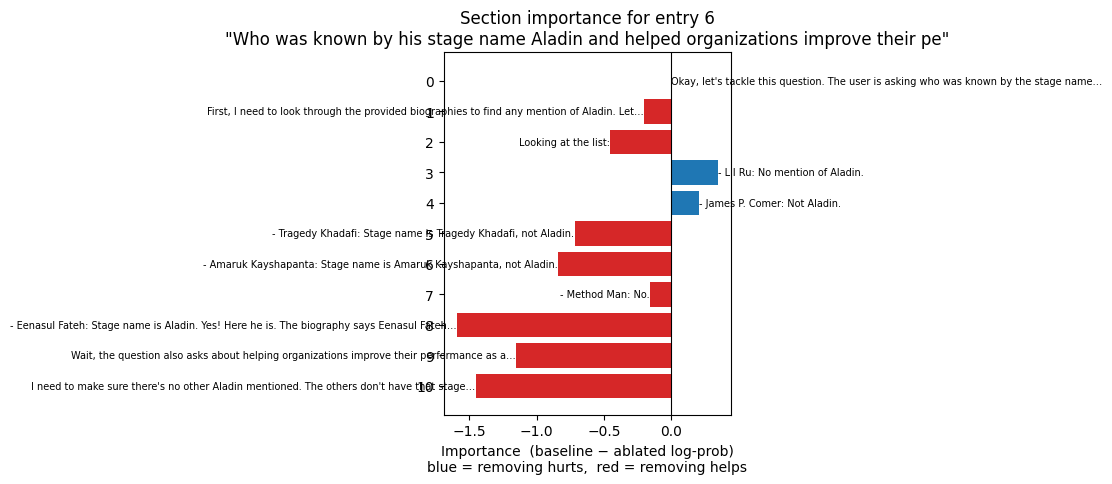

In [51]:
import matplotlib.pyplot as plt
import textwrap

fig, ax = plt.subplots(figsize=(10, max(4, len(sections) * 0.45)))

colors = ["tab:red" if v < 0 else "tab:blue" for v in df_importance["importance"]]
bars = ax.barh(df_importance["section_idx"], df_importance["importance"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

# label each bar with a truncated version of the section text
for i, (_, row) in enumerate(df_importance.iterrows()):
    label = textwrap.shorten(row["section"], width=90, placeholder="…")
    x = row["importance"]
    ha = "left" if x >= 0 else "right"
    offset = 0.001 if x >= 0 else -0.001
    ax.text(x + offset, i, label, va="center", ha=ha, fontsize=7)

ax.set_yticks(df_importance["section_idx"])
ax.set_yticklabels(df_importance["section_idx"])
ax.set_xlabel("Importance  (baseline − ablated log-prob)\nblue = removing hurts,  red = removing helps")
ax.set_title(f"Section importance for entry {ENTRY_IDX}\n\"{entry['question'][:80]}\"")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [52]:
ENTRY_IDX = 0
entry  = df_think[df_think["idx"] == ENTRY_IDX].iloc[0]
sample = hotpot_val[ENTRY_IDX]

prompt = build_hotpot_prompt(sample)
chat_prefix = think_tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    add_generation_prompt=True,
    enable_thinking=True,
    tokenize=False,
)

reasoning = entry["reasoning"]
sections  = [s for s in reasoning.split("\n") if s.strip()]
gt_answer = entry["ground_truth"]

print("Question:", entry["question"])
print("Ground truth:", gt_answer)
print("Model answer:", entry["model_answer"])
print(f"\nNumber of sections: {len(sections)}")

baseline = score_logprob(make_prefix(reasoning), gt_answer)
print(f"Baseline log-prob: {baseline:.4f}\n")

ablation_results_0 = []
for i, section in enumerate(sections):
    ablated   = "\n".join(s for j, s in enumerate(sections) if j != i)
    score     = score_logprob(make_prefix(ablated), gt_answer)
    importance = baseline - score
    ablation_results_0.append({
        "section_idx": i,
        "section":     section,
        "logprob_ablated": score,
        "importance":  importance,
    })
    print(f"[{i:2d}] {importance:+.4f}  {section[:80]}")

df_importance_0 = pd.DataFrame(ablation_results_0)
df_importance_0

Question: Were Scott Derrickson and Ed Wood of the same nationality?
Ground truth: yes
Model answer: Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American.

Number of sections: 12
Baseline log-prob: -29.3750

[ 0] +0.1250  Okay, let's see. The question is asking if Scott Derrickson and Ed Wood were of 
[ 1] -2.1250  First, I'll look at each person's background. Starting with Scott Derrickson. Th
[ 2] -1.1250  In the entry about Scott Derrickson, he's mentioned as a director, writer, and p
[ 3] +0.7500  Then there's Ed Wood. The entry says Ed Wood is a 1994 biographical film directe
[ 4] -0.8750  Wait, but the question is about Scott Derrickson and Ed Wood's nationalities. So
[ 5] +0.8750  Looking at Scott Derrickson's entry: he's an American filmmaker and director. Th
[ 6] +0.1250  Ed Wood: the entry says he's a 1994 biographical film directed by Tim Burton. Th
[ 7] -0.2500  Therefore, both Scott Derrickson and Ed Wood are American. So their nationalitie
[ 8

,section_idx,section,logprob_ablated,importance
0,0,"Okay, let's see. The question is asking if Sco...",-29.500,0.125
1,1,"First, I'll look at each person's background. ...",-27.250,-2.125
2,2,"In the entry about Scott Derrickson, he's ment...",-28.250,-1.125
3,3,Then there's Ed Wood. The entry says Ed Wood i...,-30.125,0.750
4,4,"Wait, but the question is about Scott Derricks...",-28.500,-0.875
5,5,Looking at Scott Derrickson's entry: he's an A...,-30.250,0.875
6,6,Ed Wood: the entry says he's a 1994 biographic...,-29.500,0.125
7,7,"Therefore, both Scott Derrickson and Ed Wood a...",-29.125,-0.250
8,8,"Wait, but the question is whether they were of...",-28.500,-0.875
9,9,"But wait, I need to make sure there's no other...",-30.625,1.250


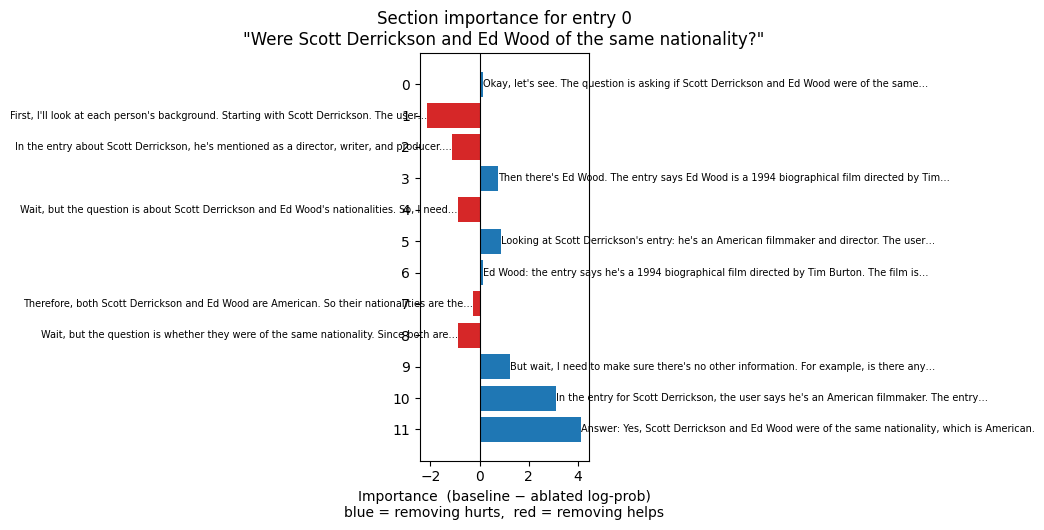

In [53]:
fig, ax = plt.subplots(figsize=(10, max(4, len(sections) * 0.45)))

colors = ["tab:red" if v < 0 else "tab:blue" for v in df_importance_0["importance"]]
ax.barh(df_importance_0["section_idx"], df_importance_0["importance"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

for _, row in df_importance_0.iterrows():
    label  = textwrap.shorten(row["section"], width=90, placeholder="…")
    x      = row["importance"]
    offset = 0.001 if x >= 0 else -0.001
    ax.text(x + offset, row["section_idx"], label, va="center",
            ha="left" if x >= 0 else "right", fontsize=7)

ax.set_yticks(df_importance_0["section_idx"])
ax.set_yticklabels(df_importance_0["section_idx"])
ax.set_xlabel("Importance  (baseline − ablated log-prob)\nblue = removing hurts,  red = removing helps")
ax.set_title(f"Section importance for entry 0\n\"{entry['question'][:80]}\"")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [54]:
def generate_from_prefix(prefix_text, max_new_tokens=80):
    """Generate answer tokens starting from a forced prefix (reasoning already closed)."""
    prefix_ids = think_tokenizer(prefix_text, return_tensors="pt")["input_ids"].to(device)
    with torch.no_grad():
        output_ids = think_model.generate(
            prefix_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=think_tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][prefix_ids.shape[1]:]
    raw = think_tokenizer.decode(new_tokens, skip_special_tokens=False)
    return re.sub(r"<\|[^|]+\|>", "", raw).strip()

# baseline generation (full reasoning)
baseline_gen = generate_from_prefix(make_prefix(reasoning))

print(f"ENTRY 0: {entry['question']}")
print(f"Ground truth: {gt_answer}\n")
print(f"{'='*80}")
print(f"BASELINE (full reasoning)")
print(f"  log-prob: {baseline:.4f}")
print(f"  generated: {baseline_gen}")
print()

for _, row in df_importance_0.iterrows():
    i       = int(row["section_idx"])
    ablated = "\n".join(s for j, s in enumerate(sections) if j != i)
    gen     = generate_from_prefix(make_prefix(ablated))
    df_importance_0.at[row.name, "generated"] = gen
    torch.cuda.empty_cache()

    print(f"[{i:2d}] importance={row['importance']:+.4f}  removed: \"{textwrap.shorten(row['section'], 70, placeholder='…')}\"")
    print(f"      generated: {gen}")
    print()

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


ENTRY 0: Were Scott Derrickson and Ed Wood of the same nationality?
Ground truth: yes

BASELINE (full reasoning)
  log-prob: -29.3750
  generated: Answer: <your answer> Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American.

[ 0] importance=+0.1250  removed: "Okay, let's see. The question is asking if Scott Derrickson and Ed…"
      generated: Answer: Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American.

[ 1] importance=-2.1250  removed: "First, I'll look at each person's background. Starting with Scott…"
      generated: Answer: Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American. Both are American filmmakers and directors. 

Answer: <your answer> Yes

[ 2] importance=-1.1250  removed: "In the entry about Scott Derrickson, he's mentioned as a director,…"
      generated: Answer: Yes, Scott Derrickson and Ed Wood were of the same nationality, which is American. Both are American filmmakers and direc

## Trying to find a challenging one

In [67]:
ENTRY_IDX = 8
entry  = df_think[df_think["idx"] == ENTRY_IDX].iloc[0]
sample = hotpot_val[ENTRY_IDX]

prompt = build_hotpot_prompt(sample)
chat_prefix = think_tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    add_generation_prompt=True,
    enable_thinking=True,
    tokenize=False,
)

reasoning = entry["reasoning"]
sections  = [s for s in reasoning.split("\n") if s.strip()]
gt_answer = entry["ground_truth"]

print("Question:", entry["question"])
print("Ground truth:", gt_answer)
print("Model answer:", entry["model_answer"])
print(f"\nNumber of sections: {len(sections)}")

baseline = score_logprob(make_prefix(reasoning), gt_answer)
print(f"Baseline log-prob: {baseline:.4f}\n")

ablation_results_8 = []
for i, section in enumerate(sections):
    ablated    = "\n".join(s for j, s in enumerate(sections) if j != i)
    score      = score_logprob(make_prefix(ablated), gt_answer)
    importance = baseline - score
    ablation_results_8.append({
        "section_idx": i,
        "section":     section,
        "logprob_ablated": score,
        "importance":  importance,
    })
    print(f"[{i:2d}] {importance:+.4f}  {section[:80]}")

df_importance_8 = pd.DataFrame(ablation_results_8)
df_importance_8

Question: Who is older, Annie Morton or Terry Richardson?
Ground truth: Terry Richardson
Model answer: Annie Morton was born on October 8, 1970. Terry Richardson's

Number of sections: 19
Baseline log-prob: -5.6562

[ 0] +1.0625  Okay, let's try to figure out who is older between Annie Morton and Terry Richar
[ 1] +3.5938  Looking at the information provided, Annie Morton was born on October 8, 1970. T
[ 2] +2.4062  Wait, the user mentioned "Terry Richardson" in the context of the James Joseph R
[ 3] +2.5312  In the section about Amanda Lepore, there's a mention of Terry Richardson. But t
[ 4] +3.0312  Annie Morton's birth date is given as October 8, 1970. Then, Terry Richardson's 
[ 5] +0.9688  Wait, the user is asking about Terry Richardson and Annie Morton. Let me check t
[ 6] +4.2812  Annie Morton: October 8, 1970.
[ 7] +2.6562  Terry Richardson: The user might be referring to Terry Richardson as the photogr
[ 8] +3.7812  Wait, in the Index Magazine section, there's a mention of Te

,section_idx,section,logprob_ablated,importance
0,0,"Okay, let's try to figure out who is older bet...",-6.71875,1.06250
1,1,"Looking at the information provided, Annie Mor...",-9.25000,3.59375
2,2,"Wait, the user mentioned ""Terry Richardson"" in...",-8.06250,2.40625
3,3,"In the section about Amanda Lepore, there's a ...",-8.18750,2.53125
4,4,Annie Morton's birth date is given as October ...,-8.68750,3.03125
5,5,"Wait, the user is asking about Terry Richardso...",-6.62500,0.96875
6,6,"Annie Morton: October 8, 1970.",-9.93750,4.28125
7,7,Terry Richardson: The user might be referring ...,-8.31250,2.65625
8,8,"Wait, in the Index Magazine section, there's a...",-9.43750,3.78125
9,9,"Wait, the user might be conflating two differe...",-6.25000,0.59375


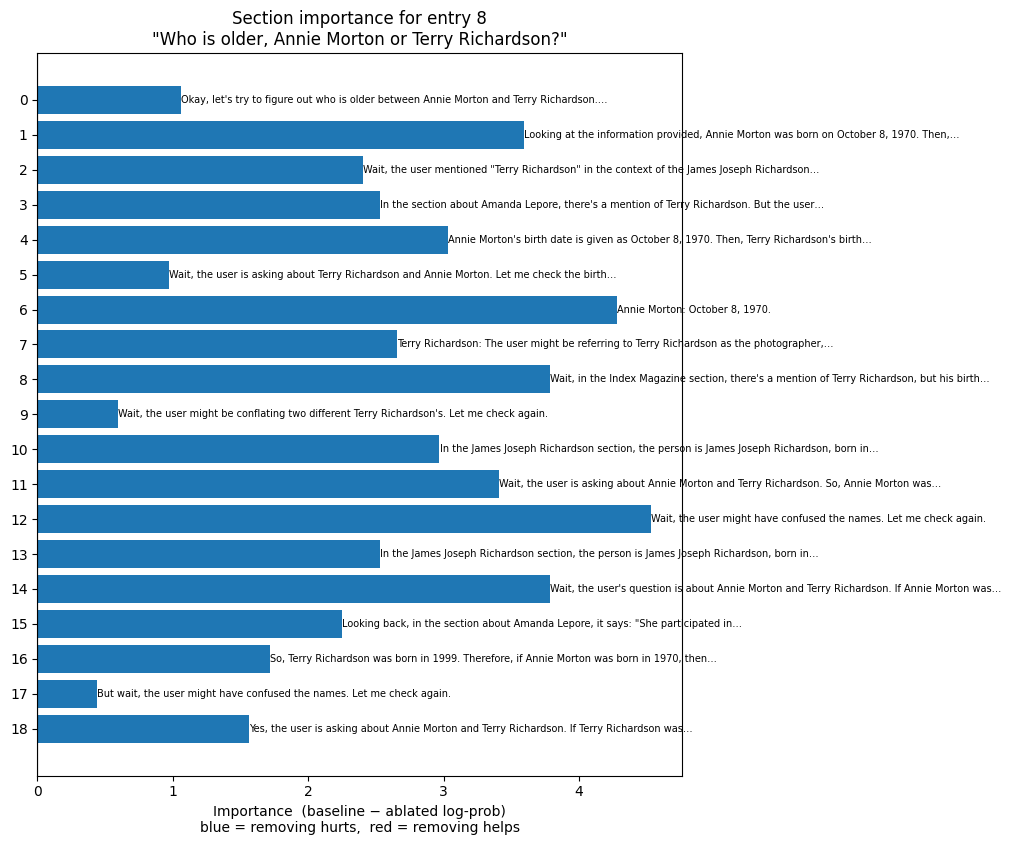

In [68]:
fig, ax = plt.subplots(figsize=(10, max(4, len(sections) * 0.45)))

colors = ["tab:red" if v < 0 else "tab:blue" for v in df_importance_8["importance"]]
ax.barh(df_importance_8["section_idx"], df_importance_8["importance"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

for _, row in df_importance_8.iterrows():
    label  = textwrap.shorten(row["section"], width=90, placeholder="…")
    x      = row["importance"]
    offset = 0.001 if x >= 0 else -0.001
    ax.text(x + offset, row["section_idx"], label, va="center",
            ha="left" if x >= 0 else "right", fontsize=7)

ax.set_yticks(df_importance_8["section_idx"])
ax.set_yticklabels(df_importance_8["section_idx"])
ax.set_xlabel("Importance  (baseline − ablated log-prob)\nblue = removing hurts,  red = removing helps")
ax.set_title(f"Section importance for entry 8\n\"{entry['question'][:80]}\"")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [69]:
def generate_from_prefix_unlimited(prefix_text):
    """Generate until EOS with no artificial token budget."""
    prefix_ids = think_tokenizer(prefix_text, return_tensors="pt")["input_ids"].to(device)
    with torch.no_grad():
        output_ids = think_model.generate(
            prefix_ids,
            do_sample=False,
            pad_token_id=think_tokenizer.eos_token_id,
            eos_token_id=think_tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][prefix_ids.shape[1]:]
    raw = think_tokenizer.decode(new_tokens, skip_special_tokens=False)
    return re.sub(r"<\|[^|]+\|>", "", raw).strip()

baseline_gen_8 = generate_from_prefix_unlimited(make_prefix(reasoning))

print(f"ENTRY 8: {entry['question']}")
print(f"Ground truth: {gt_answer}\n")
print(f"{'='*80}")
print(f"BASELINE (full reasoning)")
print(f"  log-prob:  {baseline:.4f}")
print(f"  generated: {baseline_gen_8}")
print()

for _, row in df_importance_8.iterrows():
    i       = int(row["section_idx"])
    ablated = "\n".join(s for j, s in enumerate(sections) if j != i)
    gen     = generate_from_prefix_unlimited(make_prefix(ablated))
    df_importance_8.at[row.name, "generated"] = gen
    torch.cuda.empty_cache()

    print(f"[{i:2d}] importance={row['importance']:+.4f}  removed: \"{textwrap.shorten(row['section'], 70, placeholder='…')}\"")
    print(f"      generated: {gen}")
    print()

/home/jennifer/scratch/micromamba/envs/info/lib/python3.12/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=2522) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


ENTRY 8: Who is older, Annie Morton or Terry Richardson?
Ground truth: Terry Richardson

BASELINE (full reasoning)
  log-prob:  -5.6562
  generated: Answer: Annie Morton is older than Terry Richardson.



/home/jennifer/scratch/micromamba/envs/info/lib/python3.12/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=2494) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


[ 0] importance=+1.0625  removed: "Okay, let's try to figure out who is older between Annie Morton and…"
      generated: Answer: Annie Morton is older than Terry Richardson.



/home/jennifer/scratch/micromamba/envs/info/lib/python3.12/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=2460) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


...

[16] importance=+1.7188  removed: "So, Terry Richardson was born in 1999. Therefore, if Annie Morton was…"
      generated: Answer: Annie Morton is older than Terry Richardson.



/home/jennifer/scratch/micromamba/envs/info/lib/python3.12/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=2505) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


[17] importance=+0.4375  removed: "But wait, the user might have confused the names. Let me check again."
      generated: Answer: Annie Morton is older than Terry Richardson.



/home/jennifer/scratch/micromamba/envs/info/lib/python3.12/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=2469) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


[18] importance=+1.5625  removed: "Yes, the user is asking about Annie Morton and Terry Richardson. If…"
      generated: Annie Morton was born on October 8, 1970. Terry Richardson, as



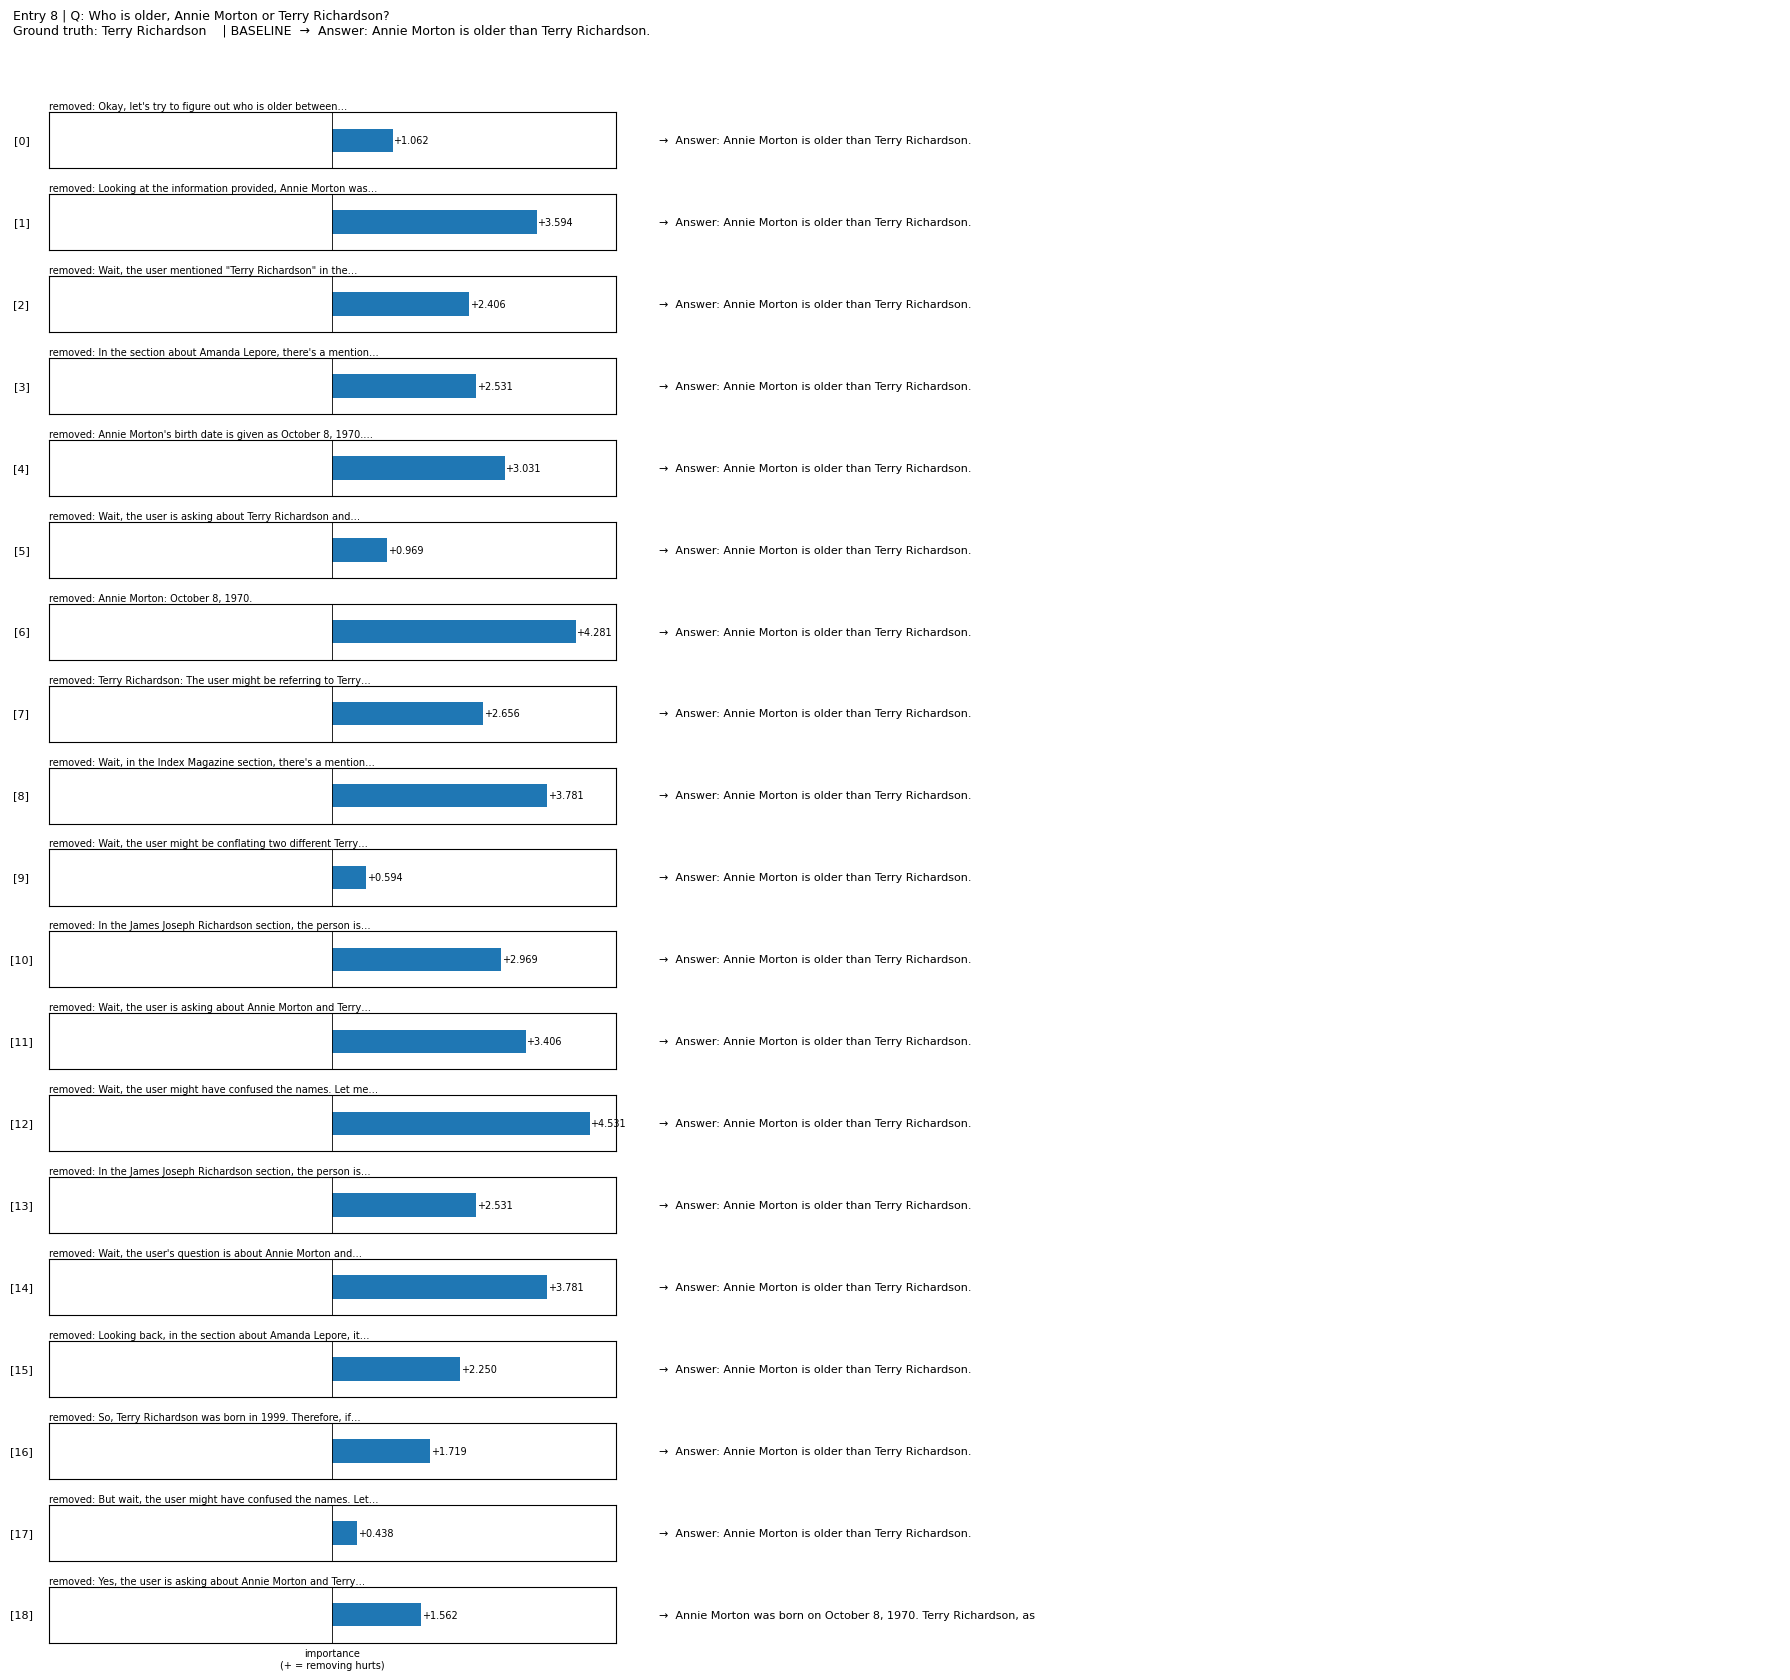

In [70]:
n = len(df_importance_8)
fig, axes = plt.subplots(n, 2, figsize=(18, n * 0.9),
                         gridspec_kw={"width_ratios": [1, 2]})

baseline_label = f"BASELINE  →  {textwrap.shorten(baseline_gen_8, 120, placeholder='…')}"
fig.suptitle(
    f"Entry 8 | Q: {entry['question'][:90]}\nGround truth: {gt_answer}    "
    f"| {baseline_label}",
    fontsize=9, ha="left", x=0.01, wrap=True
)

vmax = df_importance_8["importance"].abs().max() * 1.1 or 0.01

for ax_bar, ax_txt, (_, row) in zip(axes[:, 0], axes[:, 1], df_importance_8.iterrows()):
    i          = int(row["section_idx"])
    importance = row["importance"]
    color      = "tab:blue" if importance >= 0 else "tab:red"
    generated  = row.get("generated", "")

    # --- bar ---
    ax_bar.barh(0, importance, color=color, height=0.5)
    ax_bar.axvline(0, color="black", linewidth=0.6)
    ax_bar.set_xlim(-vmax, vmax)
    ax_bar.set_ylim(-0.6, 0.6)
    ax_bar.set_yticks([])
    ax_bar.set_xticks([])
    ax_bar.set_ylabel(f"[{i}]", rotation=0, labelpad=20, va="center", fontsize=8)
    ax_bar.text(importance + (0.002 * vmax if importance >= 0 else -0.002 * vmax),
                0, f"{importance:+.3f}", va="center",
                ha="left" if importance >= 0 else "right", fontsize=7)

    removed_label = textwrap.shorten(row["section"], 55, placeholder="…")
    ax_bar.set_title(f"removed: {removed_label}", fontsize=7, loc="left", pad=2)

    # --- generated text ---
    ax_txt.axis("off")
    gen_wrapped = textwrap.fill(generated, width=110, max_lines=3, placeholder="…")
    ax_txt.text(0.01, 0.5, f"→  {gen_wrapped}", va="center", ha="left",
                fontsize=8, transform=ax_txt.transAxes,
                color="darkgreen" if generated.lower().strip().startswith(gt_answer.lower().strip())
                      else "black")

# shared x-label on bottom bar only
axes[-1, 0].set_xlabel("importance\n(+ = removing hurts)", fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [60]:
set(ds['train']['level'])

{'easy', 'hard', 'medium'}

In [63]:
df_think.iloc[8]

idx                                                                 8
type                                                           bridge
level                                                            hard
question              Who is older, Annie Morton or Terry Richardson?
reasoning           Okay, let's try to figure out who is older bet...
final_text          Annie Morton was born on October 8, 1970. Terr...
model_answer        Annie Morton was born on October 8, 1970. Terr...
ground_truth                                         Terry Richardson
correct                                                         False
reasoning_tokens                                                 1001
Name: 8, dtype: object

In [66]:
df_think['final_text'][8]

"Annie Morton was born on October 8, 1970. Terry Richardson's"

In [76]:
ENTRY_IDX = 8
sample    = hotpot_val[ENTRY_IDX]
gt_answer = sample["answer"]

prompt = build_hotpot_prompt(sample)
inputs = think_tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    add_generation_prompt=True,
    enable_thinking=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(device)

with torch.no_grad():
    output_ids = think_model.generate(
        **inputs,
        max_new_tokens=4096,   # large enough to close </think> and write an answer
        do_sample=False,
        pad_token_id=think_tokenizer.eos_token_id,
        eos_token_id=think_tokenizer.eos_token_id,
    )

raw = think_tokenizer.decode(
    output_ids[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=False,
)
torch.cuda.empty_cache()

# debug: show raw output so we can verify <think> tags are present
print(repr(raw[:300]))


"<think>\nOkay, let's try to figure out who is older between Annie Morton and Terry Richardson. First, I need to find their birth dates.\n\nLooking at the information provided, Annie Morton was born on October 8, 1970. Then, there's a mention of Kenton Terry Richardson, who was born on July 26, 1999. Wa"


In [81]:
gen_reasoning, gen_final = parse_thinking_output(raw)
gen_answer = extract_answer_clean(gen_final)

print(f"Question:         {sample['question']}")
print(f"Ground truth:     {gt_answer}")
print(f"Generated answer: {gen_answer}")
print(f"Reasoning lines:  {len([l for l in gen_reasoning.splitlines() if l.strip()])}")
print(f"\n--- Generated reasoning ---\n")
print(gen_reasoning)


Question:         Who is older, Annie Morton or Terry Richardson?
Ground truth:     Terry Richardson
Generated answer: Annie Morton is older.
Reasoning lines:  19

--- Generated reasoning ---

Okay, let's try to figure out who is older between Annie Morton and Terry Richardson. First, I need to find their birth dates.

Looking at the information provided, Annie Morton was born on October 8, 1970. Then, there's a mention of Kenton Terry Richardson, who was born on July 26, 1999. Wait, but the question is about Annie Morton and Terry Richardson. 

Wait, the user mentioned "Terry Richardson" in the context of the James Joseph Richardson part, but that's a different person. Let me check again. 

In the section about Amanda Lepore, there's a mention of Terry Richardson. But the user is asking about Annie Morton and Terry Richardson. So, I need to confirm their birth dates.

Annie Morton's birth date is given as October 8, 1970. Then, Terry Richardson's birth date is not directly stated here

In [82]:
# Step 2: split generated reasoning into sentences, ablate each,
# score gt_answer log-prob and roll out the full response
chat_prefix_8 = think_tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    add_generation_prompt=True,
    enable_thinking=True,
    tokenize=False,
)

sentences = [s for s in gen_reasoning.splitlines() if s.strip()]

def make_prefix_8(reasoning_text):
    return chat_prefix_8 + reasoning_text + "\n</think>\n"

def rollout(prefix_text):
    """Generate until EOS from a forced prefix."""
    ids = think_tokenizer(prefix_text, return_tensors="pt")["input_ids"].to(device)
    with torch.no_grad():
        out = think_model.generate(
            ids,
            max_new_tokens=4096,
            do_sample=False,
            pad_token_id=think_tokenizer.eos_token_id,
            eos_token_id=think_tokenizer.eos_token_id,
        )
    raw = think_tokenizer.decode(out[0][ids.shape[1]:], skip_special_tokens=False)
    torch.cuda.empty_cache()
    return re.sub(r"<\|[^|]+\|>", "", raw).strip()

baseline_8   = score_logprob(make_prefix_8(gen_reasoning), gt_answer)
baseline_gen = rollout(make_prefix_8(gen_reasoning))
print(f"Baseline log-prob: {baseline_8:.4f}  ({len(sentences)} sentences)")
print(f"Baseline rollout:  {baseline_gen[:120]}\n")

sent_results = []
for i, sent in enumerate(sentences):
    ablated    = "\n".join(s for j, s in enumerate(sentences) if j != i)
    lp         = score_logprob(make_prefix_8(ablated), gt_answer)
    importance = baseline_8 - lp
    rolled     = rollout(make_prefix_8(ablated))
    sent_results.append({
        "idx":        i,
        "sentence":   sent,
        "logprob":    lp,
        "importance": importance,
        "rollout":    rolled,
    })
    print(f"[{i:2d}] {importance:+.4f}  removed: {sent[:60]}")
    print(f"       rollout: {rolled[:120]}\n")

df_sent = pd.DataFrame(sent_results)
df_sent


Baseline log-prob: -5.6562  (19 sentences)
Baseline rollout:  Answer: Annie Morton is older than Terry Richardson.

[ 0] +1.0625  removed: Okay, let's try to figure out who is older between Annie Mor
       rollout: Answer: Annie Morton is older than Terry Richardson.

[ 1] +3.5938  removed: Looking at the information provided, Annie Morton was born o
       rollout: Answer: Annie Morton is older than Terry Richardson.

[ 2] +2.4062  removed: Wait, the user mentioned "Terry Richardson" in the context o
       rollout: Answer: Annie Morton is older than Terry Richardson.

[ 3] +2.5312  removed: In the section about Amanda Lepore, there's a mention of Ter
       rollout: Answer: Annie Morton is older than Terry Richardson.

[ 4] +3.0312  removed: Annie Morton's birth date is given as October 8, 1970. Then,
       rollout: Answer: Annie Morton is older than Terry Richardson.

[ 5] +0.9688  removed: Wait, the user is asking about Terry Richardson and Annie Mo
       rollout: Answer: Annie 

,idx,sentence,logprob,importance,rollout
0,0,"Okay, let's try to figure out who is older bet...",-6.71875,1.06250,Answer: Annie Morton is older than Terry Richa...
1,1,"Looking at the information provided, Annie Mor...",-9.25000,3.59375,Answer: Annie Morton is older than Terry Richa...
2,2,"Wait, the user mentioned ""Terry Richardson"" in...",-8.06250,2.40625,Answer: Annie Morton is older than Terry Richa...
3,3,"In the section about Amanda Lepore, there's a ...",-8.18750,2.53125,Answer: Annie Morton is older than Terry Richa...
4,4,Annie Morton's birth date is given as October ...,-8.68750,3.03125,Answer: Annie Morton is older than Terry Richa...
5,5,"Wait, the user is asking about Terry Richardso...",-6.62500,0.96875,Answer: Annie Morton is older than Terry Richa...
6,6,"Annie Morton: October 8, 1970.",-9.93750,4.28125,Answer: Annie Morton is older than Terry Richa...
7,7,Terry Richardson: The user might be referring ...,-8.31250,2.65625,Answer: Annie Morton is older than Terry Richa...
8,8,"Wait, in the Index Magazine section, there's a...",-9.43750,3.78125,Answer: Annie Morton is older than Terry Richa...
9,9,"Wait, the user might be conflating two differe...",-6.25000,0.59375,Answer: Annie Morton is older than Terry Richa...


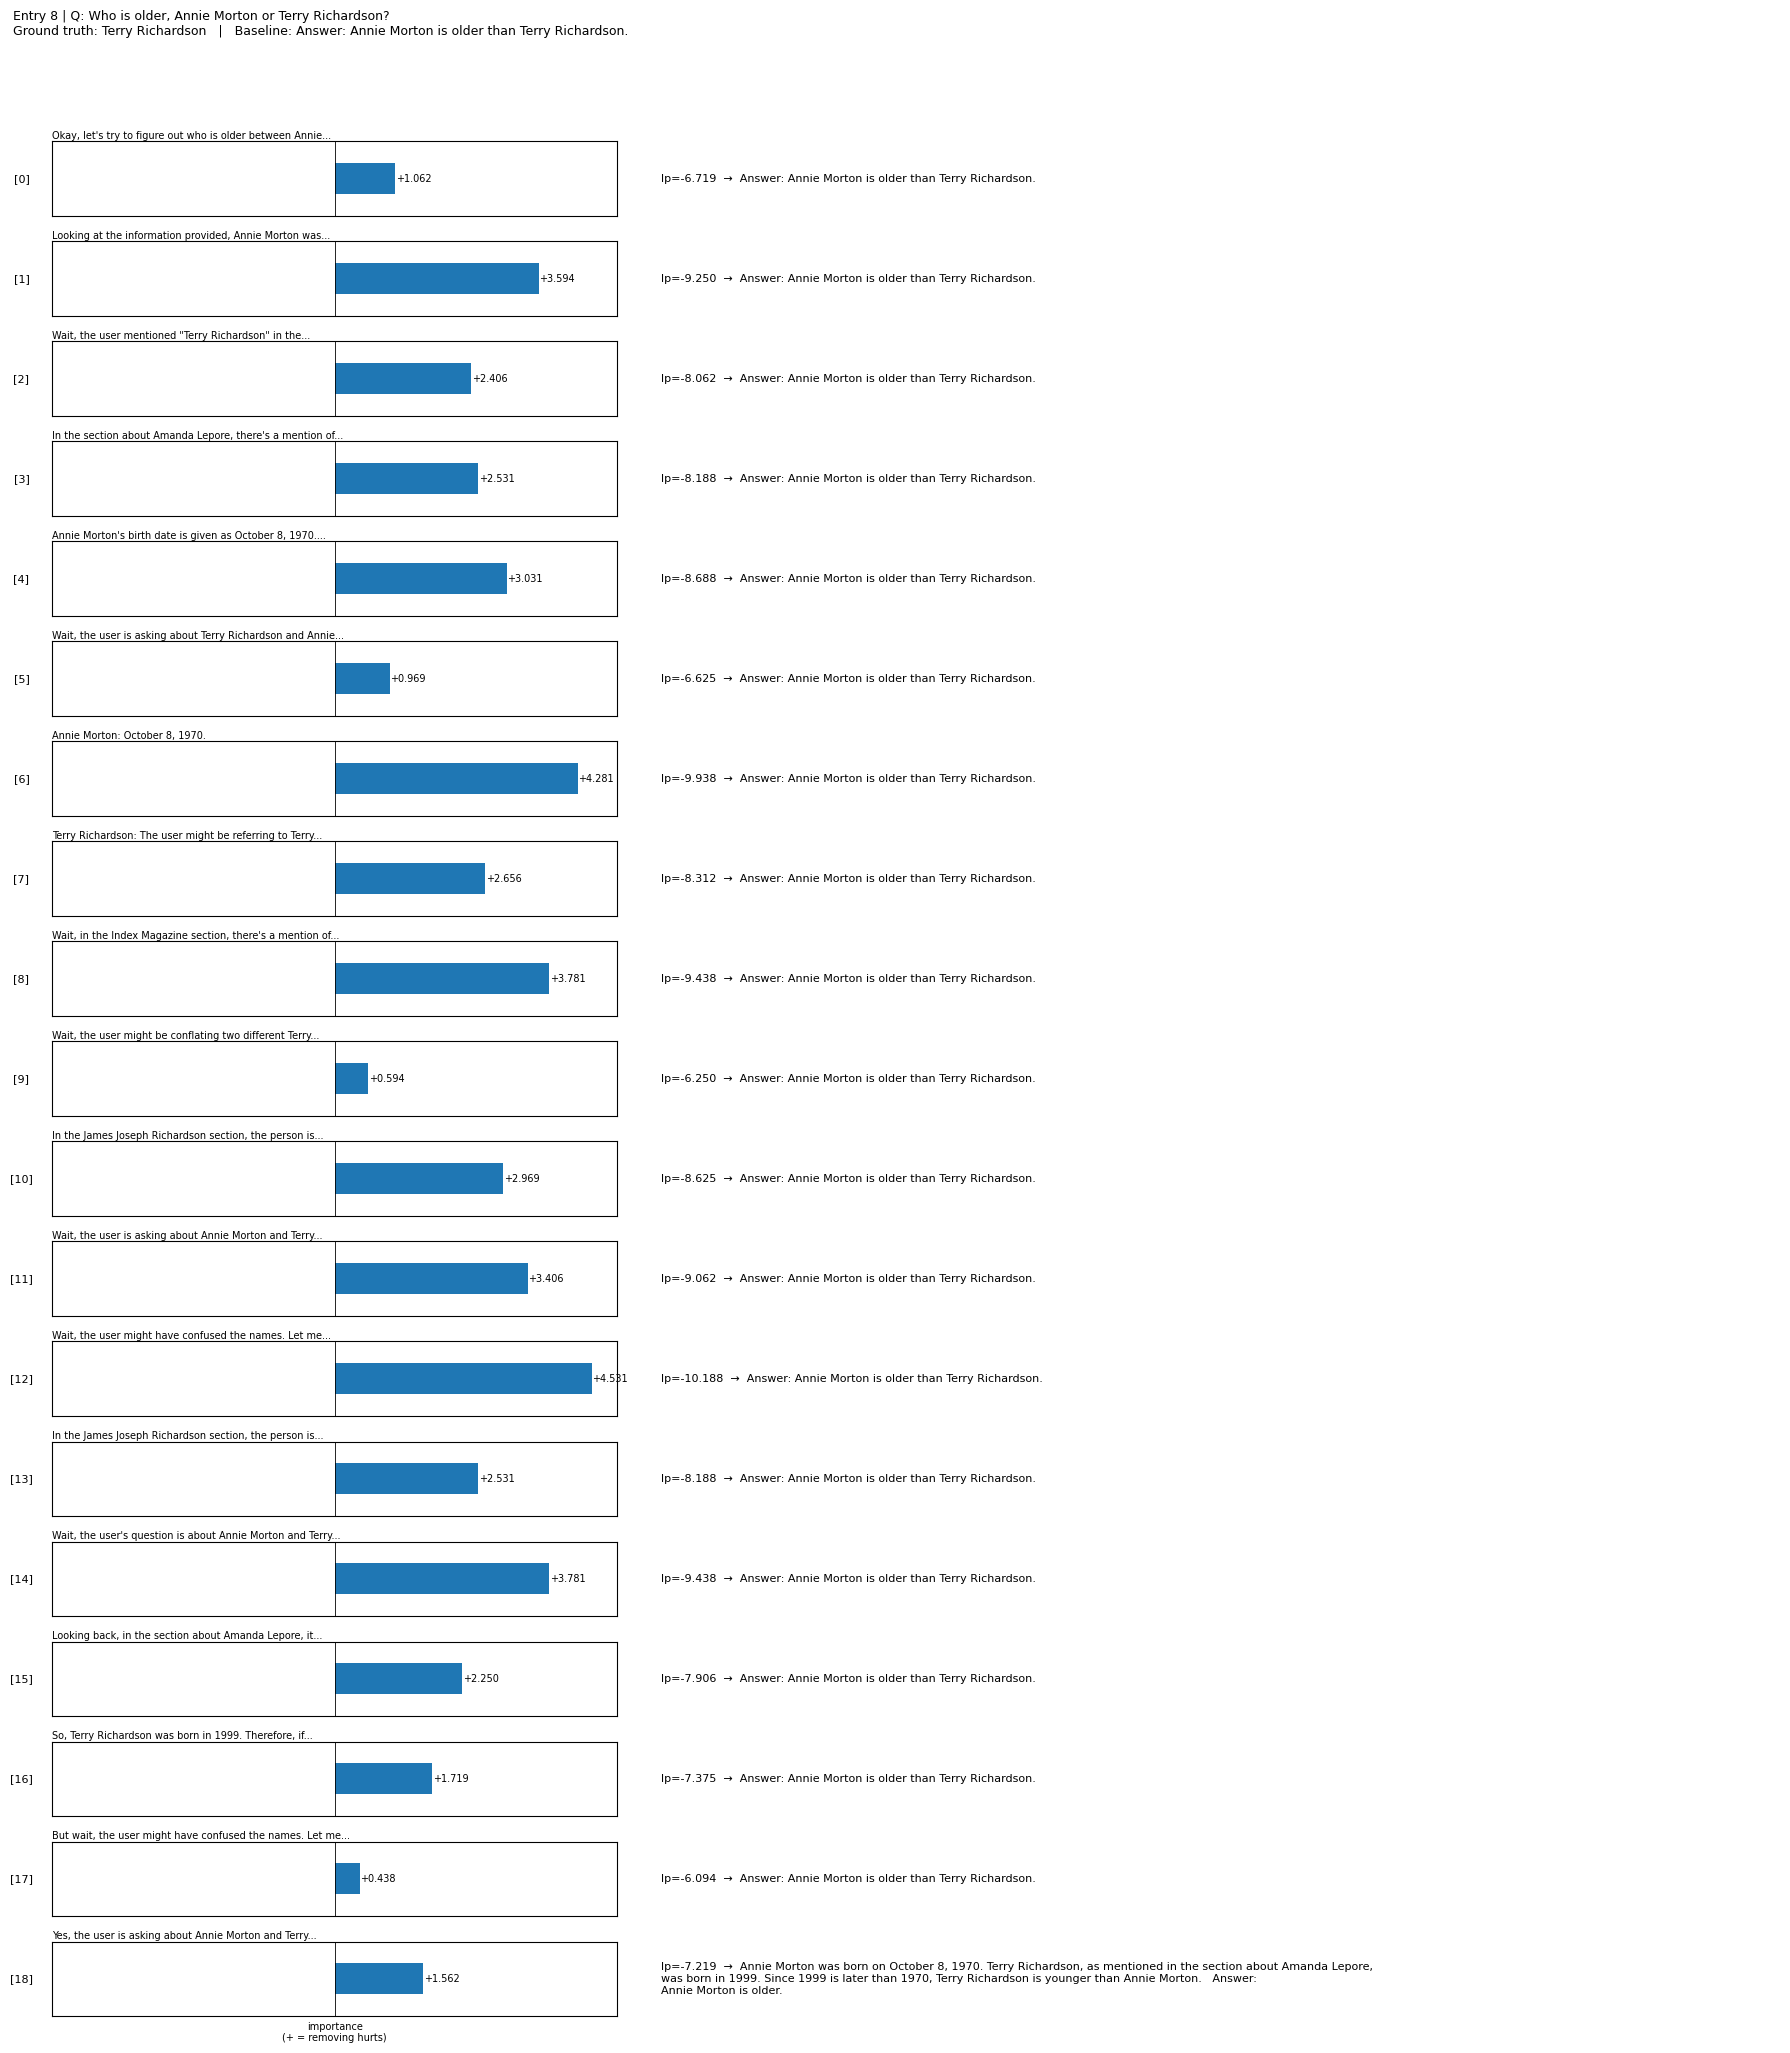

In [83]:
n    = len(df_sent)
vmax = df_sent["importance"].abs().max() * 1.1 or 0.01

fig, axes = plt.subplots(n, 2, figsize=(18, n * 1.1),
                         gridspec_kw={"width_ratios": [1, 2]})
if n == 1:
    axes = axes[None, :]

fig.suptitle(
    f"Entry 8 | Q: {sample['question'][:90]}\n"
    f"Ground truth: {gt_answer}   |   "
    f"Baseline: {textwrap.shorten(baseline_gen, 100, placeholder='...')}",
    fontsize=9, ha="left", x=0.01,
)

for ax_bar, ax_txt, (_, row) in zip(axes[:, 0], axes[:, 1], df_sent.iterrows()):
    color = "tab:blue" if row["importance"] >= 0 else "tab:red"
    ax_bar.barh(0, row["importance"], color=color, height=0.5)
    ax_bar.axvline(0, color="black", linewidth=0.6)
    ax_bar.set_xlim(-vmax, vmax)
    ax_bar.set_ylim(-0.6, 0.6)
    ax_bar.set_yticks([])
    ax_bar.set_xticks([])
    ax_bar.set_ylabel(f"[{int(row['idx'])}]", rotation=0, labelpad=22, va="center", fontsize=8)
    ax_bar.text(
        row["importance"] + (0.002 * vmax if row["importance"] >= 0 else -0.002 * vmax),
        0, f"{row['importance']:+.3f}", va="center",
        ha="left" if row["importance"] >= 0 else "right", fontsize=7,
    )
    ax_bar.set_title(textwrap.shorten(row["sentence"], 60, placeholder="..."),
                     fontsize=7, loc="left", pad=2)

    rollout_text = textwrap.fill(row["rollout"], width=110, max_lines=3, placeholder="...")
    is_correct   = row["rollout"].lower().strip().startswith(gt_answer.lower().strip())
    ax_txt.axis("off")
    ax_txt.text(
        0.01, 0.5,
        f"lp={row['logprob']:.3f}  →  {rollout_text}",
        va="center", ha="left", fontsize=8,
        color="darkgreen" if is_correct else "black",
        transform=ax_txt.transAxes,
    )

axes[-1, 0].set_xlabel("importance\n(+ = removing hurts)", fontsize=7)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
